In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

#set high default resolution
plt.rcParams['figure.dpi'] = 300

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 20

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
        
    try:
        if full_cfg["model_type"] == "cnn":
            model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
            classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [4]:
train_loader, test_loader = initialize_dataloader(
    seed=42, root="./data/mazes/", batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))
mazes = Mazes(maze_data_path)

# n_frames = 40
# resolution = (128, 128)
# correlation = (0.25,0.75)
# max_speed = 1
# train_loader, test_loader = initialize_dataloader(
#         seed=12, dataset="correlated_dots",
#         resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=batch_size,
#         batch_size=batch_size)
# inputs, labels = next(iter(test_loader))

In [5]:
def extract_weights(state_dict, excitatory, output):
    """Extract weight matrices and tau constants from state dict."""
    if excitatory:
        conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
        e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]
    else:
        if output:
            e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
        else:
            e2e = state_dict["rnn.areas.0.convs.1->1.0.weight"].detach().cpu().numpy()
        conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]
    
    return conv0, e2e, taus

def extract_output_weights(state_dict):
    """Extract weight matrices and tau constants from state dict."""
    e2e = state_dict["rnn.areas.0.out_convs.1->out.0.weight"].detach().cpu().numpy()
    return e2e


def apply_gaussian_filter(data, sigma):
    """Apply Gaussian filter to data and return filtered data with min/max values."""
    filtered_data = gaussian_filter(data, sigma=sigma)
    return filtered_data, filtered_data.min(), filtered_data.max()


def create_activity_subplot(fig, subplot_spec, data, step, title, vmin=None, vmax=None, cmap='viridis'):
    """Create a standardized activity subplot."""
    ax = fig.add_subplot(subplot_spec)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title, fontsize=8)
    return ax, im


def highlight_self_kernel(ax, is_self=False):
    """Highlight the 'self' kernel with red border or hide borders for others."""
    if is_self:
        for side in ax.spines:
            spine = ax.spines[side]
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1.5)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def plot_maze_sample(fig, outer_grid, row_idx, maze_data, sample_idx, is_correct):
    """Plot maze sample with correctness indicator."""
    ax = fig.add_subplot(outer_grid[row_idx, 0])
    ax.imshow(maze_data)
    ax.set_title(f"Sample {sample_idx} {' ✓' if is_correct else ' ✗'}", fontsize=10)
    ax.axis("off")

def plot_mean_activity_grid(fig, outer_grid, row_idx, col_idx, mean_activity, step_indices, n, m):
    """Plot mean activity across all channels in a grid layout."""
    mean_sub = outer_grid[row_idx, col_idx].subgridspec(
        n, m, height_ratios=[1]*n, hspace=0, wspace=0.02
    )
    
    mean_vmin, mean_vmax = mean_activity.min(), mean_activity.max()
    mean_ims, mean_axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, mean_sub[r, c], mean_activity[step], 
            step, f"S{step}", mean_vmin, mean_vmax
        )
        mean_ims.append(im)
        mean_axs.append(ax)
    
    # Add column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title("Mean Activity", fontsize=20, pad=10, fontweight='bold')
    
    return mean_ims, mean_axs

def plot_channel_activity(
    fig, outer, row_idx, col_idx,
    act, ch_idx, step_idxs, n, m,
    input_filter, tau, kernels, sigma_filter,
    show_kernels=True
):
    """
    Per-channel cell with a *top title row* centered over the channel,
    then an n×m activity grid, and (optionally) a kernels grid.
    """

    # --- resolve tau value (scalar or vector) ---
    if torch.is_tensor(tau):
        tau_val = tau.item() if tau.ndim == 0 else float(tau[ch_idx])
    else:
        tau_val = float(tau) if np.ndim(tau) == 0 else float(tau[ch_idx])

    # --- normalize act to numpy; accept (T,H,W) or (T,C,H,W) ---
    A = act.detach().cpu().numpy() if isinstance(act, torch.Tensor) else act
    if A.ndim == 4:   # (T, C, H, W)
        imgs = A[step_idxs, ch_idx]          # (n*m, H, W)
    elif A.ndim == 3: # (T, H, W)
        imgs = A[step_idxs]                  # (n*m, H, W)
    else:
        raise ValueError(f"Unsupported act shape {A.shape}; expected (T,H,W) or (T,C,H,W).")

    # --- layout: [title] + [activity] (+ [kernels])
    if show_kernels:
        inner = outer[row_idx, col_idx].subgridspec(
            3, 1, height_ratios=[0.18, 1.0, 0.35], hspace=0.10
        )
        idx_title, idx_act, idx_ker = 0, 1, 2
    else:
        inner = outer[row_idx, col_idx].subgridspec(
            2, 1, height_ratios=[0.18, 1.0], hspace=0.08
        )
        idx_title, idx_act = 0, 1

    # ===== Title row (centered over the channel) =====
    ax_title = fig.add_subplot(inner[idx_title])
    ax_title.text(
        0.5, 0.5, f"Channel {ch_idx}  (τ={tau_val:.2f})",
        ha='center', va='center', fontsize=20, fontweight='bold'
    )
    ax_title.axis('off')

    # ===== Activity grid =====
    vmin = float(np.nanmin(imgs)); vmax = float(np.nanmax(imgs))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0

    act_spec = inner[idx_act].subgridspec(n, m, wspace=0.04, hspace=0.04)
    for i in range(n * m):
        r, c = divmod(i, m)
        ax = fig.add_subplot(act_spec[r, c])
        ax.imshow(imgs[i], cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])

    # ===== Kernels grid (optional) =====
    if show_kernels:
        ker_list = [gaussian_filter(k, sigma=sigma_filter) for k in kernels]
        all_vals = np.concatenate([k.ravel() for k in ker_list])
        wmin, wmax = float(all_vals.min()), float(all_vals.max())
        if wmin == wmax:
            wmin, wmax = wmin - 1e-6, wmax + 1e-6

        K = len(ker_list)
        k_cols = int(np.ceil(np.sqrt(K))); k_rows = int(np.ceil(K / k_cols))
        ker_spec = inner[idx_ker].subgridspec(k_rows, k_cols, wspace=0.02, hspace=0.02)

        for k_idx, ker in enumerate(ker_list):
            rr, cc = divmod(k_idx, k_cols)
            axk = fig.add_subplot(ker_spec[rr, cc])
            axk.imshow(ker, cmap="viridis", vmin=wmin, vmax=wmax, interpolation="nearest")
            axk.set_xticks([]); axk.set_yticks([])
            if "highlight_self_kernel" in globals():
                highlight_self_kernel(axk, is_self=(k_idx == ch_idx))

# Start Here

# Evaluate

In [ ]:
# ——— User‐set paths & names ———
# Identity
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    

# wandb_name = "happy-microwave-331"
# checkpoint = 200

# ReLU
# wandb_name = "earnest-planet-436"
# checkpoint = 800

# Identity, Center-Excitation
# wandb_name = "rose-elevator-396"
# checkpoint = 360

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# ReLU, with I->I recurrence, BEST
wandb_name = "golden-universe-515"
checkpoint = 320

wandb_name, checkpoint = "dauntless-elevator-522", 390 # ReLU, with I->I recurrence

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

classifier.load_state_dict(state_dict)

In [ ]:
classifier.to(device)
classifier.eval()
total_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for x, labels in tqdm(test_loader):
        x = x.to(device)
        labels = labels.to(device)
        
        logits = classifier(x, num_steps=20)
        
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(accuracy)

# Plot Everything

In [7]:
# ——— User‐set paths & names ———
# Identity
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    

# wandb_name = "happy-microwave-331"
# checkpoint = 200

# ReLU
# wandb_name = "earnest-planet-436"
# checkpoint = 800

# ReLU, with I->I recurrence
# wandb_name = "confused-haze-455"
# checkpoint = 1240

# Identity, Center-Excitation
# wandb_name = "rose-elevator-396"
# checkpoint = 360

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# ReLU, with I->I recurrence, BEST
wandb_name = "golden-universe-515"
checkpoint = 320

wandb_name, checkpoint = "dauntless-elevator-522", 390 #Identity interneuron

## CORRELATED DOTS ##
# wandb_name, checkpoint = "fancy-silence-24", 370 #BIOPLNN
# wandb_name, checkpoint = "glowing-deluge-31", 330 #CNN

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint_path)

model.eval()
# model.to(device)

classifier.eval()
# classifier.to(device)

# ——— Plot settings ———
excitatory = True
input_channel = -1 # 0 is walls, -1 is starting points
plot_maze = False
n, m = 3, 3  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
output = False  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]
channels_to_plot = None #[1]  # None plots all channels, or specify list like [0, 2, 5] for specific channels
samples_to_plot = [1,2,3] #None #[12, 13] #[5, 6, 7, 8, 9, 10, 11, 12, 13] #None #[1, 2, 3, 4] #[1]  # None plots all samples, or specify list like [0, 2, 5] for specific samples
do_highlight_self_kernel = True
show_kernels_row = True

do_output_analysis = False

# ——— Extract weight‐matrices & taus ———
conv0, e2e, taus = extract_weights(state_dict, excitatory, output)
input_filters = conv0[:, input_channel]  # ⇒ (C, H, W)

# -- Cheating a bit to do output analysis --- super lazy
if do_output_analysis:
    e2e = extract_output_weights(state_dict)

# Precompute channel count and filter channels if specified
C = input_filters.shape[0]
if channels_to_plot is not None:
    # Validate channel indices
    if not all(0 <= ch < C for ch in channels_to_plot):
        raise ValueError(f"Channel indices must be between 0 and {C-1}")
    channel_indices = channels_to_plot
    C_plot = len(channel_indices)
else:
    channel_indices = list(range(C))
    C_plot = C

# Number of columns for activity: one per channel (+1 for maze)
num_cols = C_plot + 1 + (1 if plot_maze else 0)

# Filter samples if specified
if samples_to_plot is not None:
    # Validate sample indices
    if not all(0 <= s < len(inputs) for s in samples_to_plot):
        raise ValueError(f"Sample indices must be between 0 and {len(inputs)-1}")
    sample_indices = samples_to_plot
    num_inputs = len(sample_indices)
else:
    sample_indices = list(range(len(inputs)))
    num_inputs = len(inputs)

# Setup main figure
fig = plt.figure(figsize=(3 * num_cols * m, 15 * num_inputs))
# Calculate width ratios dynamically based on what we're plotting
if plot_maze:
    width_ratios = [1] + [2] + [2] * C_plot
else:
    width_ratios = [2] + [2] * C_plot

outer = fig.add_gridspec(
    num_inputs, num_cols,
    width_ratios=width_ratios,
    hspace=0.2, wspace=0.1
)

# Pre-filter kernels for consistent color scaling
full_wvmin, full_wvmax = np.inf, -np.inf
for j in channel_indices:
    kernels = e2e[:, j] if output else e2e[j, :]
    for k in range(len(kernels)):
        kernels[k] = gaussian_filter(kernels[k], sigma=sigma_filter)
    wvmin, wvmax = kernels.min(), kernels.max()
    full_wvmin = min(full_wvmin, wvmin)
    full_wvmax = max(full_wvmax, wvmax)

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    # Compute activity for sample i
    out = classifier(inp.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    output_states, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)

    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    if do_output_analysis:
        act = output_states[0][0].detach().cpu()

    T = act.shape[0]
    step_idxs = np.linspace(0, T - 1, n * m, dtype=int)

    # Plot maze if desired
    col_offset = 0
    if plot_maze:
        plot_maze_sample(fig, outer, plot_idx, mazes.tensor_to_image(inp), sample_idx, correct)
        col_offset = 1
    
    # Compute and plot mean activity
    mean_act = torch.mean(act, dim=1)
    plot_mean_activity_grid(fig, outer, plot_idx, col_offset, mean_act, step_idxs, n, m)
    col_offset += 1

    # Plot each channel
    for channel_plot_idx, j in enumerate(channel_indices):
        col = channel_plot_idx + col_offset
        kernels = e2e[:, j] if output else e2e[j, :]
        
        plot_channel_activity(
            fig, outer, plot_idx, col, act, j, step_idxs, n, m,
            input_filters[j], taus[j], kernels, sigma_filter,
            show_kernels=show_kernels_row
        )

plt.tight_layout()
plt.show()

/tmp/ipykernel_2844260/635104040.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

/tmp/ipykernel_2844260/233573927.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [ ]:
for sample_idx in sample_indices:
    inp, label = inputs[sample_idx], labels[sample_idx]
    plt.imshow(mazes.tensor_to_image(inp))
    plt.axis("off")
    plt.show()

# Just Kernels

In [ ]:
model

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ——— Plot settings ———
excitatory = False
sigma_filter = 1.0  # optional blur for weights
output = True  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]
do_highlight_self_kernel = True

# --- Extract weights & build filtered_kernels as before ---
conv0, e2e, taus = extract_weights(state_dict, excitatory, output)

filtered_kernels = {}
all_channels = np.arange(e2e.shape[1] if output else e2e.shape[0])
channel_indices = all_channels if channels_to_plot is None else np.array(channels_to_plot)

for j in channel_indices:
    raw_kernels = e2e[:, j] if output else e2e[j, :]
    filtered_kernels[j] = [apply_gaussian_filter(k, sigma_filter)[0] for k in raw_kernels]

# --- Channel grid (moderately tight) ---
n_channels = len(channel_indices)
grid_cols = int(math.ceil(math.sqrt(n_channels)))
grid_rows = int(math.ceil(n_channels / grid_cols))

fig = plt.figure(figsize=(3.4 * grid_cols, 3.1 * grid_rows))  # a bit smaller than before
outer = fig.add_gridspec(grid_rows, grid_cols, wspace=0.15, hspace=0.18)

for idx, ch in enumerate(channel_indices):
    row, col = divmod(idx, grid_cols)

    kernels = filtered_kernels[ch]
    K = len(kernels)
    k_cols = int(math.ceil(math.sqrt(K)))
    k_rows = int(math.ceil(K / k_cols))

    # per-channel color scale
    all_vals = np.concatenate([k.ravel() for k in kernels])
    vmin, vmax = float(all_vals.min()), float(all_vals.max())

    inner = outer[row, col].subgridspec(k_rows, k_cols, wspace=0.06, hspace=0.06)
    for k_idx, kernel in enumerate(kernels):
        r, c = divmod(k_idx, k_cols)
        ax = fig.add_subplot(inner[r, c])
        ax.imshow(kernel, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        # optional highlight
        if 'highlight_self_kernel' in globals():
            highlight_self_kernel(ax, is_self=(k_idx == ch))

        # small in-axis label instead of a separate title axis
        if k_idx == 0:
            ax.text(0.02, 0.02, f"Ch {ch}",
                    transform=ax.transAxes, ha='left', va='bottom',
                    fontsize=9, fontweight='bold', color='white',
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')])

# modest suptitle and margins (less white space, not cramped)
fig.suptitle("Kernels per Channel", fontsize=13, y=0.97)
plt.tight_layout()
plt.subplots_adjust(left=0.04, right=0.98, top=0.93, bottom=0.06)
plt.show()


In [ ]:
state_dict.keys()

# Just activity

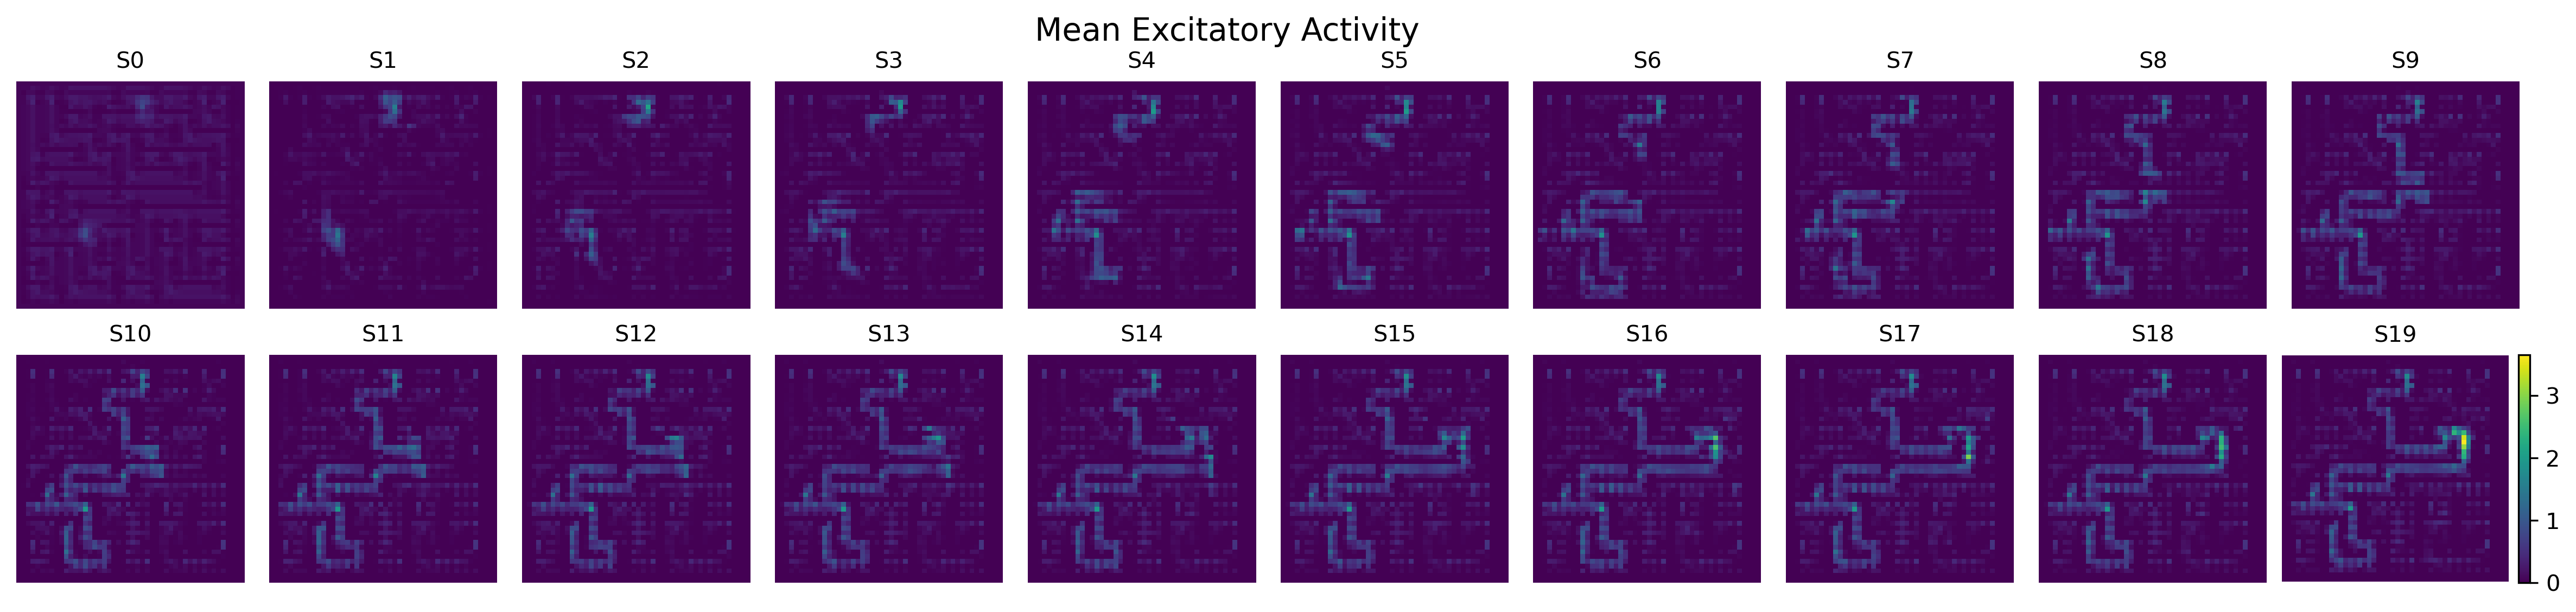

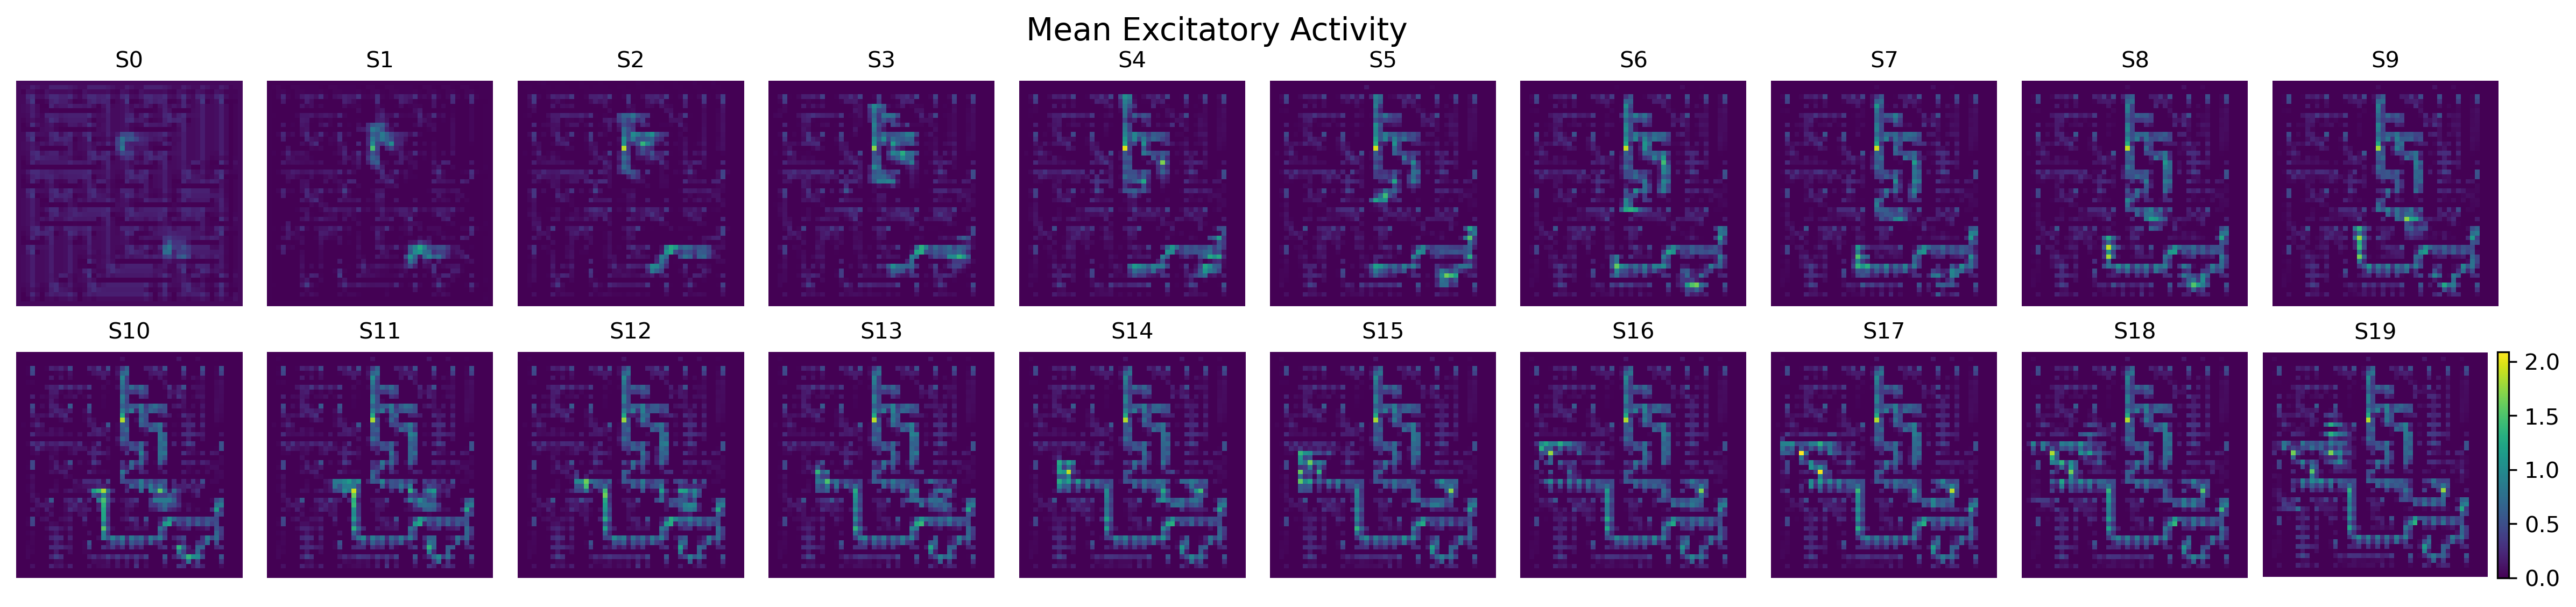

In [9]:
def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idx,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity[:, channel_idx])
    vmax = torch.max(activity[:, channel_idx])
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step, channel_idx], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def plot_mean_channel_activity(
    activity,       # array of shape [T, C, H, W]
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    activity = torch.mean(activity, dim=1)
    vmin = torch.min(activity)
    vmax = torch.max(activity)
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Mean Excitatory Activity", fontsize=14, y=0.98)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

# ——— Load model config & instantiate ———
# model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# # ——— Load checkpoint & weights ———
# try:
#     state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
# except:
#     state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
# model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
excitatory = True
n, m = 2, 10  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = np.arange(8)
sample_indices = [12, 13]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    plot_mean_channel_activity(activity, n, m)

    # for channel_idx in channels_to_plot:
    #     plot_channel_activity_solo(
    #                 activity, channel_idx, n, m)

# E and I

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_activity_overlay_panels(
    ex_activity,     # ndarray[T, H, W]: excitatory frames
    inh_activity,    # ndarray[T, H, W]: inhibitory frames
    e_channel,
    inh_channel,
    n, m,             # ints: grid layout (n rows × m cols)
    alpha=0.5
):
    """
    Plot excitatory (green) and inhibitory (red) activity overlaid
    in a n×m grid. No return; just shows the figure.
    """
    ex_activity = ex_activity[:, e_channel]   # excitatory
    inh_activity = inh_activity[:, inh_channel]   # inhibitory, for example

    T = ex_activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # sanity checks
    if ex_activity.shape != inh_activity.shape:
        raise ValueError("ex_activity and inh_activity must have the same shape")
    total = len(step_indices)
    if total > n * m:
        raise ValueError(f"{total} panels won't fit in a {n}×{m} grid")
    
    # compute shared color‐scale over all selected frames
    vmin = torch.min(torch.min(ex_activity), torch.min(inh_activity))
    vmax = torch.max(torch.max(ex_activity), torch.max(inh_activity))

    # create figure + gridspec
    fig = plt.figure(figsize=(m*3, n*3))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.1)
    fig.suptitle(f"e_channel: {e_channel}, inh_channel: {inh_channel}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])

        exc = ex_activity[step]
        inh = inh_activity[step]

        # show excitation
        im0 = ax.imshow(exc, cmap="Greens", vmin=vmin, vmax=vmax)
        # overlay inhibition
        im1 = ax.imshow(inh, cmap="Reds", vmin=vmin, vmax=vmax, alpha=alpha)

        ax.set_title(f"S{step}", fontsize=10)
        ax.axis("off")

        # only add one colorbar (here for excitation)
        if idx == total - 1:
            cbar = fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("activity")

    plt.show()


# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
n, m = 4, 5  # activity grid dims
e_channels = np.arange(0, 8)
inh_channels = np.arange(0, 4)
sample_indices = [7]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    exc = model.query_neuron_states(neuron_states, 0, 0) \
                .detach().cpu()[0]  # shape (T, C)
    inh = model.query_neuron_states(neuron_states, 0, 1) \
                .detach().cpu()[0]  # shape (T, C)

    for e_channel in e_channels:
        for inh_channel in inh_channels:
            plot_activity_overlay_panels(
                ex_activity=exc,
                inh_activity=inh,
                e_channel = e_channel,
                inh_channel = inh_channel,
                n=n, m=m
            )

# Checking for Negatives

In [ ]:
wandb_name    = "twilight-spaceship-341"
excitatory = True

for checkpoint in [10, 20, 30, 40, 50, 100, 150, 200, 250, 300, 350, 390]:
    print(checkpoint)

    # ——— Load model config & instantiate ———
    model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

    # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
    model.load_state_dict(prepare_rnn_weights(state_dict))

    _, neuron_states, _ = model(inputs, num_steps=20)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu()
    has_negative = (activity < 0).any()
    print("Contains negative values:", has_negative)

In [83]:
import numpy as np
import imageio
from math import ceil, sqrt
from PIL import Image, ImageDraw, ImageFont

try:
    import torch
    _HAS_TORCH = True
except Exception:
    _HAS_TORCH = False

def _to_numpy_uint8(x, vmin=None, vmax=None):
    if _HAS_TORCH and isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]
    if x.dtype == np.uint8:
        return x
    if np.issubdtype(x.dtype, np.integer):
        return np.clip(x, 0, 255).astype(np.uint8)
    if np.issubdtype(x.dtype, np.floating):
        vmin = float(np.nanmin(x)) if vmin is None else vmin
        vmax = float(np.nanmax(x)) if vmax is None else vmax
        if vmax == vmin:
            return np.zeros_like(x, dtype=np.uint8)
        return (np.clip((x - vmin)/(vmax - vmin), 0, 1)*255).astype(np.uint8)
    return x.astype(np.uint8)

def _tile_grid(images, ncols=None, pad=0):
    assert len(images) > 0
    h, w = images[0].shape[:2]
    ch = 1 if images[0].ndim == 2 else images[0].shape[2]
    for im in images:
        assert im.shape[:2] == (h, w), "All tiles must share size."
    n = len(images)
    if ncols is None:
        ncols = int(ceil(sqrt(n)))
    nrows = int(ceil(n / ncols))
    if ch == 1:
        canvas = np.zeros((nrows*h + pad*(nrows-1),
                           ncols*w + pad*(ncols-1)), dtype=np.uint8)
    else:
        canvas = np.zeros((nrows*h + pad*(nrows-1),
                           ncols*w + pad*(ncols-1),
                           ch), dtype=np.uint8)
    for idx, im in enumerate(images):
        r, c = divmod(idx, ncols)
        r0 = r*(h + pad); c0 = c*(w + pad)
        canvas[r0:r0+h, c0:c0+w, ...] = im
    return canvas

def _annotate_frame(arr_uint8, text, xy=(8, 8), fill=(255,255,255), bg=(0,0,0,160), pad=4, font=None):
    """
    Draw a small rounded-rect label with text onto an RGB/gray frame.
    """
    im = Image.fromarray(arr_uint8 if arr_uint8.ndim == 3
                         else np.repeat(arr_uint8[..., None], 3, axis=2))
    draw = ImageDraw.Draw(im, "RGBA")
    font = font or ImageFont.load_default()
    tw, th = draw.textbbox((0,0), text, font=font)[2:]
    x, y = xy
    box = (x - pad, y - pad, x + tw + pad, y + th + pad)
    draw.rounded_rectangle(box, radius=6, fill=bg)
    draw.text((x, y), text, font=font, fill=fill)
    return np.asarray(im)

def save_gif_from_array(
    arr, out_file="combined.gif", fps=10, ncols=None, pad=0,
    vmin=None, vmax=None,
    show_frame_idx=True, every_k=5, label_fmt="t={t}",
    label_xy=(8,8), label_text_color=(255,255,255), label_bg=(0,0,0,160), label_pad=4
):
    """
    Combine multiple sequences into a single grid GIF, with optional frame index labels.

    arr:      [n_figs, n_frames, H, W(,C)] or [n_frames, H, W(,C)], torch or numpy
    fps:      frames per second
    ncols:    grid cols (None -> square-ish)
    pad:      pixels between tiles
    vmin/vmax: normalization for float inputs
    show_frame_idx: overlay a label (e.g., 't=17') on frames
    every_k:  annotate only every k-th frame (1 = every frame)
    label_*:  styling/position of the label
    """
    if _HAS_TORCH and isinstance(arr, torch.Tensor):
        arr = arr.detach().cpu().numpy()
    arr = np.asarray(arr)

    # normalize rank
    if arr.ndim == 3:              # [T,H,W]
        arr = arr[None, ...]
    elif arr.ndim == 4 and arr.shape[-1] in (1,3,4):  # [T,H,W,C]
        arr = arr[None, ...]
    elif arr.ndim not in (4,5):
        raise ValueError("arr must be [n_figs, n_frames, H, W(,C)] or [n_frames, H, W(,C)].")

    n_figs, n_frames = arr.shape[:2]

    frames = []
    for t in range(n_frames):
        ims_t = []
        for i in range(n_figs):
            x = arr[i, t]
            x = _to_numpy_uint8(x, vmin=vmin, vmax=vmax)
            ims_t.append(x)

        # harmonize to RGB if any tile is color; drop alpha
        has_color = any(im.ndim == 3 and im.shape[-1] in (3,4) for im in ims_t)
        if has_color:
            _new = []
            for im in ims_t:
                if im.ndim == 2:
                    im = np.repeat(im[..., None], 3, axis=2)
                elif im.ndim == 3 and im.shape[-1] == 1:
                    im = np.repeat(im, 3, axis=2)
                elif im.ndim == 3 and im.shape[-1] == 4:
                    im = im[..., :3]
                _new.append(im)
            ims_t = _new

        tiled = _tile_grid(ims_t, ncols=ncols, pad=pad)

        if show_frame_idx and (t % every_k == 0):
            text = label_fmt.format(t=t)
            tiled = _annotate_frame(
                tiled, text, xy=label_xy,
                fill=label_text_color, bg=label_bg, pad=label_pad
            )

        frames.append(tiled)

    imageio.mimsave(out_file, frames, duration=1.0/float(fps), loop=0)
    print(f"Saved {out_file}: {n_frames} frames @ {fps} fps.")



In [15]:
def get_activations(model, classifier, num_samples, loader, decision_step, num_steps=20, dim=48, device=None):
    if device is None:
        device = next(model.parameters()).device

    # choose a subset of indices
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # mirror original loader settings where possible
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,  # keep consistent ordering for preallocation fill
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False
    )

    # preallocate
    e_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    i_a = np.zeros((num_samples, num_steps, 4, dim, dim), dtype=np.float32)
    o_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    model.eval()
    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)

            # core model forward once
            batch_output_states, batch_neuron_states, batch_feedback_states = model(
                batch_inputs, num_steps=num_steps
            )

            # --- collect O ---
            # your original code: batch_output_states[0] (shape: [B, T, 8, H, W])
            o = batch_output_states[0].detach().cpu().numpy()  # (B, T, 8, dim, dim)

            # --- collect E and I via query_neuron_states ---
            # your original code: query_neuron_states(states, layer_idx, 0 for 'e', 1 for 'i')
            e = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu().numpy()  # (B, T, 8, dim, dim)
            i_ = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu().numpy() # (B, T, 4, dim, dim)

            # --- decisions in the same pass ---
            # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
            pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            e_a[sl, :, :, :, :] = e
            i_a[sl, :, :, :, :] = i_
            o_a[sl, :, :, :, :] = o
            decisions[sl] = dec

            sample_idx += bsz

    return e_a, i_a, o_a, decisions, dataloader

In [18]:
## CORRELATED DOTS ##

wandb_name, checkpoint = "fancy-silence-24", 370 #BIOPLNN
# wandb_name, checkpoint = "glowing-deluge-31", 330 #CNN

## MAZES ##

# wandb_name, checkpoint = "golden-universe-515", 320 # ReLU, with I->I recurrence

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg = load_model_and_config(wandb_name, checkpoint_path)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

/tmp/ipykernel_3683706/1960763977.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
       

In [124]:
batch_size = 128
num_train_samples = batch_size * 10
num_test_samples = 16

# DOTS

n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
max_speed = 1
train_loader, test_loader = initialize_dataloader(
        seed=12, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=0.25, max_speed=max_speed, samples_per_epoch=num_train_samples,
        batch_size=batch_size)
decision_step = n_frames
num_steps = n_frames
dim = resolution[0]

# DOTS GOING ONE DIRECTION

#NEED TO FIGURE OUT WTF IS GOING ON HERE
# label_to_keep = [0,1,2,3,4,5,6,7]
# train_loader = keep_only_label_from_loader(train_loader, label_to_keep)
# num_samples = len(train_loader.dataset)

# train_ea, train_ia, train_oa, train_decisions, trainloader = get_activations(model, classifier, num_train_samples, train_loader, decision_step, num_steps=num_steps,dim=dim)
# samples = list(train_loader)

# SEE HOW ACTIVITY PERSISTS WITH NO INPUT

In [103]:
sample_idx = 5
act = train_ea[sample_idx]
act = act.reshape(act.shape[1], act.shape[0], act.shape[2], act.shape[3])
sample = samples[0][0][sample_idx, :, 0].unsqueeze(0).numpy()
frames = np.concatenate([sample, act], axis=0)

In [104]:
save_gif_from_array(frames, "combined.gif", fps=12, ncols=9, pad=2,
                    show_frame_idx=True, every_k=1, label_fmt="t={t}")

Saved combined.gif: 100 frames @ 12 fps.


In [105]:
out = np.cumsum(frames, axis=1)
out.shape

(9, 100, 128, 128)

In [106]:
save_gif_from_array(out, "combined_added.gif", fps=12, ncols=9, pad=2,
                    show_frame_idx=True, every_k=1, label_fmt="t={t}")

Saved combined_added.gif: 100 frames @ 12 fps.


In [119]:
def keep_only_label_from_loader(loader, target_labels, batch_size=None, shuffle=False):
    xs, ys = [], []
    for x, y in loader:
        # make labels 1-D over batch
        if y.ndim > 1:
            # if one-hot/probabilities, reduce to class id
            if y.size(-1) > 1:
                y_flat = y.argmax(dim=-1)
            else:
                y_flat = y.squeeze(-1)
        else:
            y_flat = y

        mask = False
        for label in target_labels:
            mask = mask | (y_flat == label)
        if mask.any():
            xs.append(x[mask, ...])                # index batch dim only
            ys.append(y_flat[mask])

    if not xs:
        raise ValueError(f"No samples with label {target_label}.")

    X = torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)
    ds = TensorDataset(X, Y)
    return DataLoader(
        ds,
        batch_size or loader.batch_size,
        shuffle=shuffle,
        num_workers=loader.num_workers,
        pin_memory=loader.pin_memory,
        drop_last=loader.drop_last,
    )

In [139]:
all_accuracies = {}
model.eval()
correct = 0
total = 0

loaders = {}
for label_to_keep in tqdm([0,1,2,3,4,5,6,7]):
    loaders[label_to_keep] = keep_only_label_from_loader(train_loader, [label_to_keep])

for ablated_channel_idx in np.arange(8):
    accuracies = []

    # neuron_ablation_config = {1: {ablated_channel_idx: "zero"}}
    # ablater = {
    #     step: {0: Ablation(neuron_ablation_config=neuron_ablation_config)}
    #     for step in range(num_steps)
    # }

    #Ablate all inhibitory connections to a channel
    connection_ablation_config = {
        "2->0": 
        {
            (0, ablated_channel_idx): "zero",
            (1, ablated_channel_idx): "zero",
            (2, ablated_channel_idx): "zero",
            (3, ablated_channel_idx): "zero"
        }
    }     

    connection_ablation_config = {
        "1->0":
        {
            (ablated_channel_idx, ablated_channel_idx): "zero",
        }
    } 
    
    ablater = {
            step: {0: Ablation(connection_ablation_config=connection_ablation_config)}
            for step in range(num_steps)
        }

    for label_to_keep in tqdm([0,1,2,3,4,5,6,7]):
        loader = loaders[label_to_keep]
        with torch.no_grad():
            for x, labels in loader:
                x = x.to(device)

                if cfg["model_type"] == "cnn":
                    x = x[:, :, 0, :, :]
                    logits = classifier(x).detach().cpu()
                else:
                    logits = classifier(x, num_steps=None, ablater=ablater).detach().cpu()

                if labels.ndim == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)       # [N, 1] -> [N]
                elif labels.ndim != 1:
                    raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracies.append(correct/total)
    all_accuracies[ablated_channel_idx] = (accuracies)

100%|██████████| 8/8 [00:04<00:00,  1.63it/s]


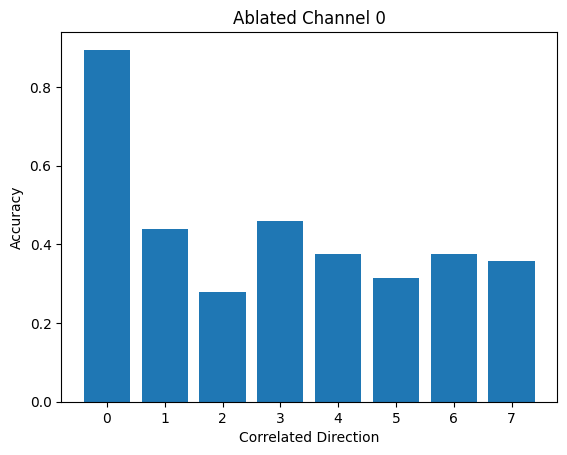

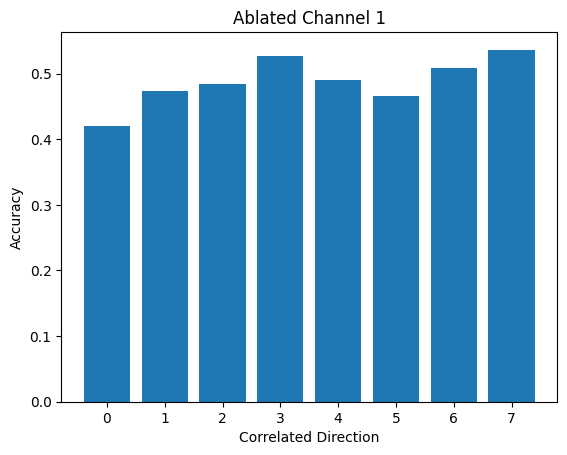

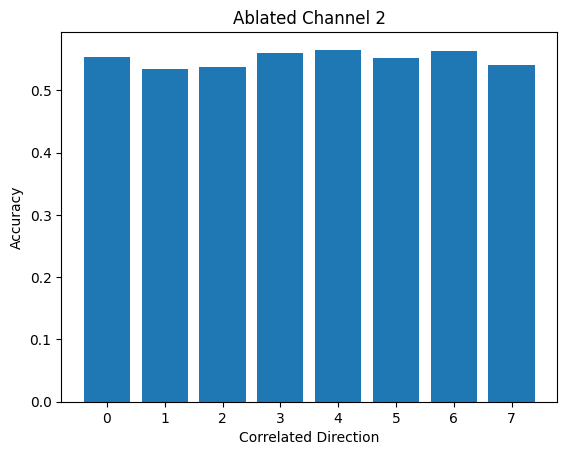

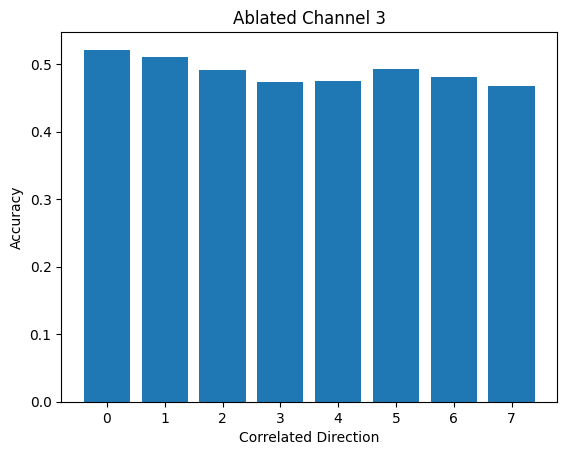

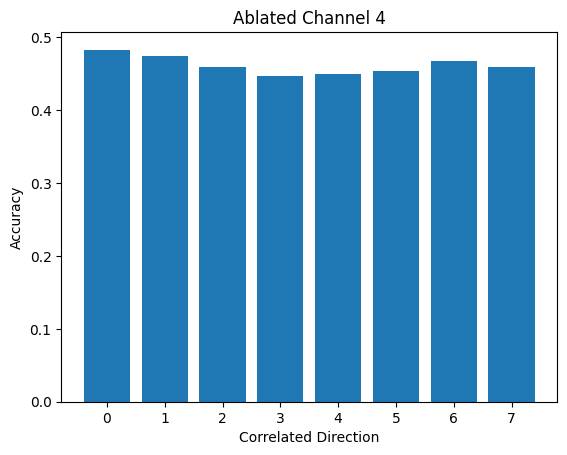

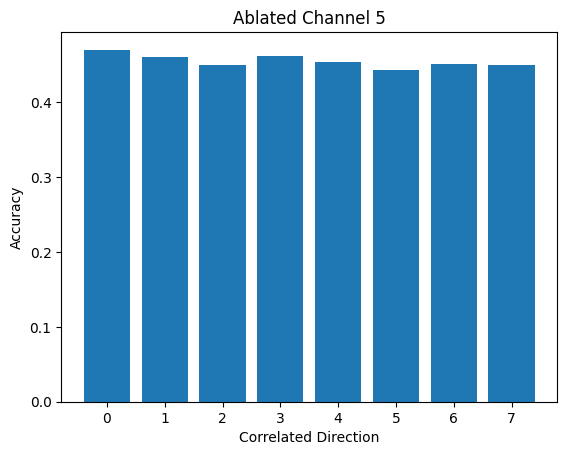

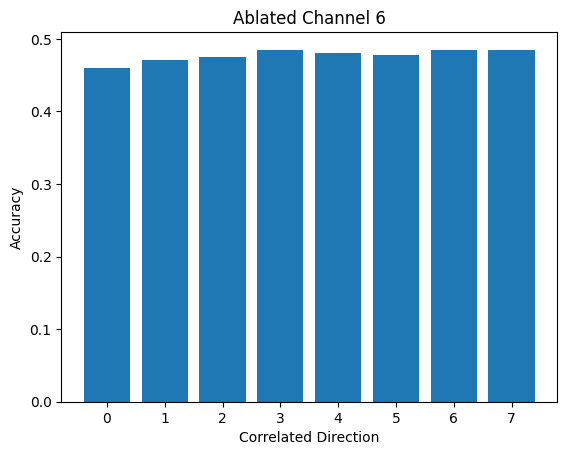

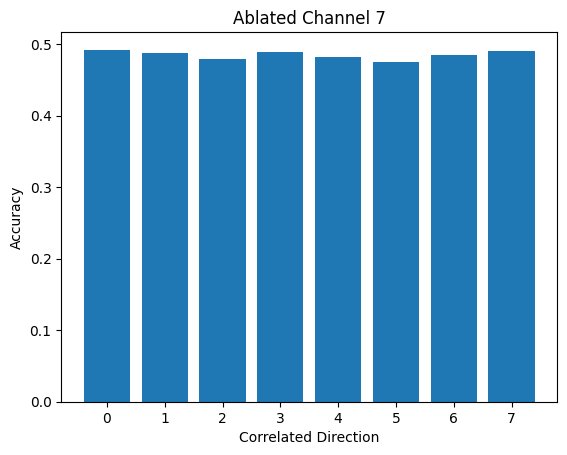

In [127]:
for ablated_channel_idx in np.arange(8):
    plt.bar(np.arange(8), all_accuracies[ablated_channel_idx])
    plt.title(f"Ablated Channel {ablated_channel_idx}")
    plt.xlabel("Correlated Direction")
    plt.ylabel("Accuracy")
    plt.show()

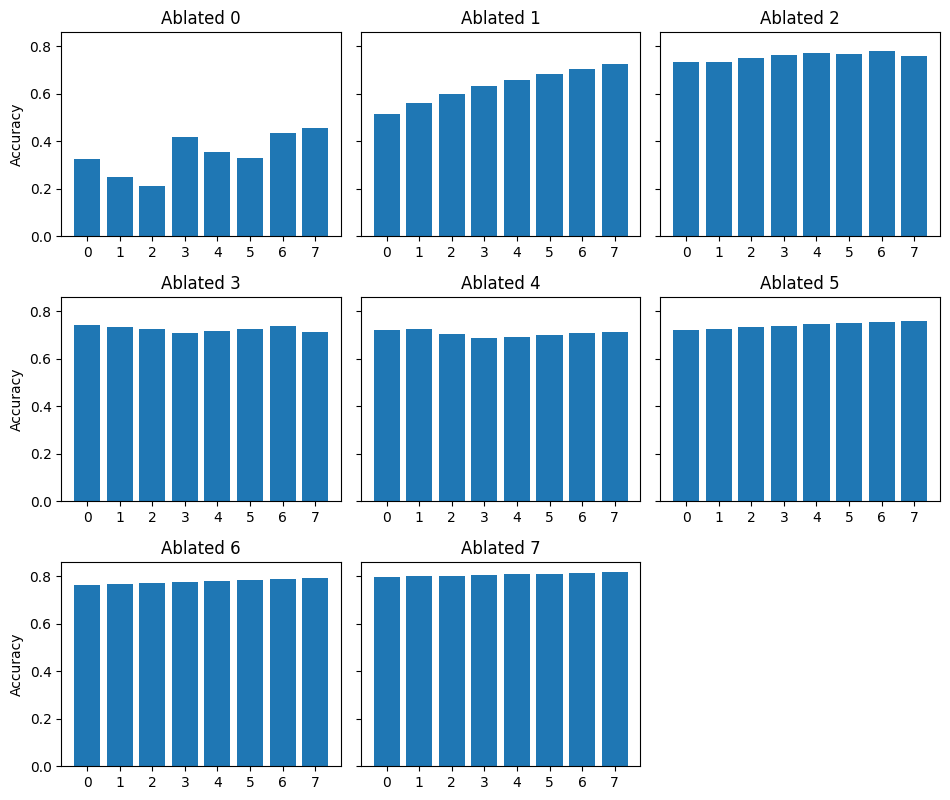

In [140]:
import numpy as np, matplotlib.pyplot as plt, math

keys = sorted(all_accuracies)                   # e.g., channel ids
n = len(keys)
ncols = int(math.ceil(math.sqrt(n))); nrows = math.ceil(n / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.7*nrows), sharey=True)
ax = np.ravel(ax)

x = np.arange(len(all_accuracies[keys[0]]))
for i, k in enumerate(keys):
    a = ax[i]; a.bar(x, all_accuracies[k]); a.set_title(f"Ablated {k}")
    a.set_xticks(x)
    if i % ncols == 0: a.set_ylabel("Accuracy")
for a in ax[n:]: a.axis("off")

fig.tight_layout(); plt.show()


In [ ]:
def extract_weights(state_dict, excitatory, output):
    """Extract weight matrices and tau constants from state dict."""
    if excitatory:
        conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
        e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]
    else:
        if output:
            e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
        else:
            e2e = state_dict["rnn.areas.0.convs.1->1.0.weight"].detach().cpu().numpy()
        conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]
    
    return conv0, e2e, taus

def extract_output_weights(state_dict):
    """Extract weight matrices and tau constants from state dict."""
    e2e = state_dict["rnn.areas.0.out_convs.1->out.0.weight"].detach().cpu().numpy()
    return e2e


def apply_gaussian_filter(data, sigma):
    """Apply Gaussian filter to data and return filtered data with min/max values."""
    filtered_data = gaussian_filter(data, sigma=sigma)
    return filtered_data, filtered_data.min(), filtered_data.max()


def create_activity_subplot(fig, subplot_spec, data, step, title, vmin=None, vmax=None, cmap='viridis'):
    """Create a standardized activity subplot."""
    ax = fig.add_subplot(subplot_spec)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title, fontsize=8)
    return ax, im


def highlight_self_kernel(ax, is_self=False):
    """Highlight the 'self' kernel with red border or hide borders for others."""
    if is_self:
        for side in ax.spines:
            spine = ax.spines[side]
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1.5)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def plot_maze_sample(fig, outer_grid, row_idx, maze_data, sample_idx, is_correct):
    """Plot maze sample with correctness indicator."""
    ax = fig.add_subplot(outer_grid[row_idx, 0])
    ax.imshow(maze_data)
    ax.set_title(f"Sample {sample_idx} {' ✓' if is_correct else ' ✗'}", fontsize=10)
    ax.axis("off")


def plot_mean_activity_grid(fig, outer_grid, row_idx, col_idx, mean_activity, step_indices, n, m):
    """Plot mean activity across all channels in a grid layout."""
    mean_sub = outer_grid[row_idx, col_idx].subgridspec(
        n, m, height_ratios=[1]*n, hspace=0, wspace=0.02
    )
    
    mean_vmin, mean_vmax = mean_activity.min(), mean_activity.max()
    mean_ims, mean_axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, mean_sub[r, c], mean_activity[step], 
            step, f"S{step}", mean_vmin, mean_vmax
        )
        mean_ims.append(im)
        mean_axs.append(ax)
    
    # Add column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title("Mean Activity", fontsize=20, pad=10, fontweight='bold')
    
    return mean_ims, mean_axs

def plot_channel_activity(
    fig, outer, row_idx, col_idx,
    act, ch_idx, step_idxs, n, m,
    input_filter, tau, kernels, sigma_filter,
    show_kernels=True
):
    """
    Per-channel cell with a *top title row* centered over the channel,
    then an n×m activity grid, and (optionally) a kernels grid.
    """

    # --- resolve tau value (scalar or vector) ---
    if torch.is_tensor(tau):
        tau_val = tau.item() if tau.ndim == 0 else float(tau[ch_idx])
    else:
        tau_val = float(tau) if np.ndim(tau) == 0 else float(tau[ch_idx])

    # --- normalize act to numpy; accept (T,H,W) or (T,C,H,W) ---
    A = act.detach().cpu().numpy() if isinstance(act, torch.Tensor) else act
    if A.ndim == 4:   # (T, C, H, W)
        imgs = A[step_idxs, ch_idx]          # (n*m, H, W)
    elif A.ndim == 3: # (T, H, W)
        imgs = A[step_idxs]                  # (n*m, H, W)
    else:
        raise ValueError(f"Unsupported act shape {A.shape}; expected (T,H,W) or (T,C,H,W).")

    # --- layout: [title] + [activity] (+ [kernels])
    if show_kernels:
        inner = outer[row_idx, col_idx].subgridspec(
            3, 1, height_ratios=[0.18, 1.0, 0.35], hspace=0.10
        )
        idx_title, idx_act, idx_ker = 0, 1, 2
    else:
        inner = outer[row_idx, col_idx].subgridspec(
            2, 1, height_ratios=[0.18, 1.0], hspace=0.08
        )
        idx_title, idx_act = 0, 1

    # ===== Title row (centered over the channel) =====
    ax_title = fig.add_subplot(inner[idx_title])
    ax_title.text(
        0.5, 0.5, f"Channel {ch_idx}  (τ={tau_val:.2f})",
        ha='center', va='center', fontsize=20, fontweight='bold'
    )
    ax_title.axis('off')

    # ===== Activity grid =====
    vmin = float(np.nanmin(imgs)); vmax = float(np.nanmax(imgs))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0

    act_spec = inner[idx_act].subgridspec(n, m, wspace=0.04, hspace=0.04)
    for i in range(n * m):
        r, c = divmod(i, m)
        ax = fig.add_subplot(act_spec[r, c])
        ax.imshow(imgs[i], cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])

    # ===== Kernels grid (optional) =====
    if show_kernels:
        ker_list = [gaussian_filter(k, sigma=sigma_filter) for k in kernels]
        all_vals = np.concatenate([k.ravel() for k in ker_list])
        wmin, wmax = float(all_vals.min()), float(all_vals.max())
        if wmin == wmax:
            wmin, wmax = wmin - 1e-6, wmax + 1e-6

        K = len(ker_list)
        k_cols = int(np.ceil(np.sqrt(K))); k_rows = int(np.ceil(K / k_cols))
        ker_spec = inner[idx_ker].subgridspec(k_rows, k_cols, wspace=0.02, hspace=0.02)

        for k_idx, ker in enumerate(ker_list):
            rr, cc = divmod(k_idx, k_cols)
            axk = fig.add_subplot(ker_spec[rr, cc])
            axk.imshow(ker, cmap="viridis", vmin=wmin, vmax=wmax, interpolation="nearest")
            axk.set_xticks([]); axk.set_yticks([])
            if "highlight_self_kernel" in globals():
                highlight_self_kernel(axk, is_self=(k_idx == ch_idx))

In [ ]:
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps


def extract_weights(state_dict, excitatory, output):
    """Extract weight matrices and tau constants from state dict."""
    if excitatory:
        conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
        e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]
    else:
        if output:
            e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
        else:
            e2e = state_dict["rnn.areas.0.convs.1->1.0.weight"].detach().cpu().numpy()
        conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]
    
    return conv0, e2e, taus

def extract_output_weights(state_dict):
    """Extract weight matrices and tau constants from state dict."""
    e2e = state_dict["rnn.areas.0.out_convs.1->out.0.weight"].detach().cpu().numpy()
    return e2e


def apply_gaussian_filter(data, sigma):
    """Apply Gaussian filter to data and return filtered data with min/max values."""
    filtered_data = gaussian_filter(data, sigma=sigma)
    return filtered_data, filtered_data.min(), filtered_data.max()


def create_activity_subplot(fig, subplot_spec, data, step, title, vmin=None, vmax=None, cmap='viridis'):
    """Create a standardized activity subplot."""
    ax = fig.add_subplot(subplot_spec)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title, fontsize=8)
    return ax, im


def highlight_self_kernel(ax, is_self=False):
    """Highlight the 'self' kernel with red border or hide borders for others."""
    if is_self:
        for side in ax.spines:
            spine = ax.spines[side]
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1.5)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def plot_maze_sample(fig, outer_grid, row_idx, maze_data, sample_idx, is_correct):
    """Plot maze sample with correctness indicator."""
    ax = fig.add_subplot(outer_grid[row_idx, 0])
    ax.imshow(maze_data)
    ax.set_title(f"Sample {sample_idx} {' ✓' if is_correct else ' ✗'}", fontsize=10)
    ax.axis("off")


def plot_mean_activity_grid(fig, outer_grid, row_idx, col_idx, mean_activity, step_indices, n, m):
    """Plot mean activity across all channels in a grid layout."""
    mean_sub = outer_grid[row_idx, col_idx].subgridspec(
        n, m, height_ratios=[1]*n, hspace=0, wspace=0.02
    )
    
    mean_vmin, mean_vmax = mean_activity.min(), mean_activity.max()
    mean_ims, mean_axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, mean_sub[r, c], mean_activity[step], 
            step, f"S{step}", mean_vmin, mean_vmax
        )
        mean_ims.append(im)
        mean_axs.append(ax)
    
    # Add column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title("Mean Activity", fontsize=20, pad=10, fontweight='bold')
    
    return mean_ims, mean_axs

def plot_channel_activity(
    fig, outer, row_idx, col_idx,
    act, ch_idx, step_idxs, n, m,
    input_filter, tau, kernels, sigma_filter,
    show_kernels=True
):
    """
    Per-channel cell with a *top title row* centered over the channel,
    then an n×m activity grid, and (optionally) a kernels grid.
    """

    # --- resolve tau value (scalar or vector) ---
    if torch.is_tensor(tau):
        tau_val = tau.item() if tau.ndim == 0 else float(tau[ch_idx])
    else:
        tau_val = float(tau) if np.ndim(tau) == 0 else float(tau[ch_idx])

    # --- normalize act to numpy; accept (T,H,W) or (T,C,H,W) ---
    A = act.detach().cpu().numpy() if isinstance(act, torch.Tensor) else act
    if A.ndim == 4:   # (T, C, H, W)
        imgs = A[step_idxs, ch_idx]          # (n*m, H, W)
    elif A.ndim == 3: # (T, H, W)
        imgs = A[step_idxs]                  # (n*m, H, W)
    else:
        raise ValueError(f"Unsupported act shape {A.shape}; expected (T,H,W) or (T,C,H,W).")

    # --- layout: [title] + [activity] (+ [kernels])
    if show_kernels:
        inner = outer[row_idx, col_idx].subgridspec(
            3, 1, height_ratios=[0.18, 1.0, 0.35], hspace=0.10
        )
        idx_title, idx_act, idx_ker = 0, 1, 2
    else:
        inner = outer[row_idx, col_idx].subgridspec(
            2, 1, height_ratios=[0.18, 1.0], hspace=0.08
        )
        idx_title, idx_act = 0, 1

    # ===== Title row (centered over the channel) =====
    ax_title = fig.add_subplot(inner[idx_title])
    ax_title.text(
        0.5, 0.5, f"Channel {ch_idx}  (τ={tau_val:.2f})",
        ha='center', va='center', fontsize=20, fontweight='bold'
    )
    ax_title.axis('off')

    # ===== Activity grid =====
    vmin = float(np.nanmin(imgs)); vmax = float(np.nanmax(imgs))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0

    act_spec = inner[idx_act].subgridspec(n, m, wspace=0.04, hspace=0.04)
    for i in range(n * m):
        r, c = divmod(i, m)
        ax = fig.add_subplot(act_spec[r, c])
        ax.imshow(imgs[i], cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])

    # ===== Kernels grid (optional) =====
    if show_kernels:
        ker_list = [gaussian_filter(k, sigma=sigma_filter) for k in kernels]
        all_vals = np.concatenate([k.ravel() for k in ker_list])
        wmin, wmax = float(all_vals.min()), float(all_vals.max())
        if wmin == wmax:
            wmin, wmax = wmin - 1e-6, wmax + 1e-6

        K = len(ker_list)
        k_cols = int(np.ceil(np.sqrt(K))); k_rows = int(np.ceil(K / k_cols))
        ker_spec = inner[idx_ker].subgridspec(k_rows, k_cols, wspace=0.02, hspace=0.02)

        for k_idx, ker in enumerate(ker_list):
            rr, cc = divmod(k_idx, k_cols)
            axk = fig.add_subplot(ker_spec[rr, cc])
            axk.imshow(ker, cmap="viridis", vmin=wmin, vmax=wmax, interpolation="nearest")
            axk.set_xticks([]); axk.set_yticks([])
            if "highlight_self_kernel" in globals():
                highlight_self_kernel(axk, is_self=(k_idx == ch_idx))